# **Task 1: Comparative LLM Fine-Tuning — Medical Question Answering**

## 1. Environment Setup

In [ ]:
!pip install -q \
    "transformers>=4.44.0,<4.46.0" \
    "peft>=0.11.0,<0.13.0" \
    "datasets>=2.19.0" \
    "evaluate>=0.4.0" \
    "sacrebleu>=2.3.1" \
    "rouge_score>=0.1.2" \
    "accelerate>=0.30.0" \
    "bitsandbytes>=0.43.0" \
    "sentencepiece>=0.1.99" \
    "tqdm"

print("Installation complete. If you see import errors below, go to Runtime > Restart session.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.0 MB/s eta 0:00:00
Installation complete. If you see import errors below, go to Runtime > Restart session.


In [ ]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
    EarlyStoppingCallback,
)
from datasets import load_dataset, DatasetDict
import evaluate

from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    PeftModel,
    get_peft_model_state_dict,
)

warnings.filterwarnings('ignore')
set_seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## **2. Dataset Loading & Preprocessing**

In [ ]:
raw_dataset = load_dataset("pubmed_qa", "pqa_labeled", trust_remote_code=True)
print(raw_dataset)
print("\nSample entry:")
sample = raw_dataset["train"][0]
print(f"  Question    : {sample['question'][:120]}...")
print(f"  Long answer : {sample['long_answer'][:120]}...")
print(f"  Decision    : {sample['final_decision']}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'pubmed_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'pubmed_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})

Sample entry:
  Question    : Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?...
  Long answer : Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation o...
  Decision    : yes


In [ ]:
full_data = raw_dataset["train"].shuffle(seed=42)
n = len(full_data)  # 1000 samples

train_size = int(0.70 * n)   # 700 samples
val_size   = int(0.15 * n)   # 150 samples
test_size  = n - train_size - val_size  # 150 samples

train_data = full_data.select(range(train_size))
val_data   = full_data.select(range(train_size, train_size + val_size))
test_data  = full_data.select(range(train_size + val_size, n))

splits = DatasetDict({"train": train_data, "validation": val_data, "test": test_data})
print(f"Train: {len(train_data)} | Validation: {len(val_data)} | Test: {len(test_data)}")

Train: 700 | Validation: 150 | Test: 150


In [ ]:
MODEL_NAME       = "google/flan-t5-base"
MAX_INPUT_LEN    = 512
MAX_TARGET_LEN   = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def build_input(example):
    """Concatenate question + first 3 context sentences into a prompt."""
    ctx_sentences = example["context"]["contexts"]  # list of strings
    context_text = " ".join(ctx_sentences[:3])
    return f"medical question: {example['question']} context: {context_text}"

def tokenize(batch):
    inputs  = [build_input(ex) for ex in batch["context"] and
               [dict(question=batch["question"][i],
                     context=batch["context"][i])
                for i in range(len(batch["question"]))]]
    targets = batch["long_answer"]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LEN,
        padding="max_length",
        truncation=True,
    )
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,
            max_length=MAX_TARGET_LEN,
            padding="max_length",
            truncation=True,
        )
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]
    model_inputs["labels"] = label_ids
    return model_inputs

def preprocess(examples):
    prompts = []
    for i in range(len(examples["question"])):
        ctx_list = examples["context"][i]["contexts"][:3]
        context_str = " ".join(ctx_list)
        prompts.append(f"medical question: {examples['question'][i]} context: {context_str}")

    model_inputs = tokenizer(
        prompts,
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["long_answer"],
            max_length=MAX_TARGET_LEN,
            truncation=True,
        )
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in lbl]
        for lbl in labels["input_ids"]
    ]
    model_inputs["labels"] = label_ids
    return model_inputs

tokenised_splits = splits.map(preprocess, batched=True, remove_columns=splits["train"].column_names)
print("Tokenised splits:", tokenised_splits)
print("\nFeatures:", tokenised_splits["train"].features)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Tokenised splits: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 700
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})

Features: {'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


## **3. Evaluation Utilities**

In [ ]:
rouge_metric = evaluate.load("rouge")
bleu_metric  = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    if isinstance(preds, np.ndarray) and preds.dtype == object:
        decoded_preds = [
            tokenizer.decode(
                [t for t in p if t != -100 and t != tokenizer.pad_token_id],
                skip_special_tokens=True,
            )
            for p in preds
        ]
    else:
        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    if isinstance(labels, np.ndarray) and labels.dtype == object:
        decoded_labels = [
            tokenizer.decode(
                [t for t in l if t != -100 and t != tokenizer.pad_token_id],
                skip_special_tokens=True,
            )
            for l in labels
        ]
    else:
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    rouge_result = rouge_metric.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True
    )

    bleu_result = bleu_metric.compute(
        predictions=decoded_preds, references=[[l] for l in decoded_labels]
    )

    result = {
        "rouge1" : round(rouge_result["rouge1"] * 100, 2),
        "rouge2" : round(rouge_result["rouge2"] * 100, 2),
        "rougeL" : round(rouge_result["rougeL"] * 100, 2),
        "bleu"   : round(bleu_result["score"],           2),
    }
    return result

def evaluate_model(model, dataset, desc="Evaluating", batch_size=32):
    """Run beam search decoding on `dataset` and return metric scores."""
    model.eval()
    device = next(model.parameters()).device
    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=data_collator)

    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc=desc):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"]   # keep on CPU

        with torch.no_grad():
            generated = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=MAX_TARGET_LEN,
                num_beams=2,              # beam=2 is ~2× faster than beam=4
            )
        all_preds.extend([seq.cpu().numpy() for seq in generated])
        all_labels.extend([lbl.numpy() for lbl in labels])

    return compute_metrics((np.array(all_preds, dtype=object), np.array(all_labels, dtype=object)))

print("Evaluation utilities loaded.")


Evaluation utilities loaded.


## **4. Baseline Evaluation (Pre-trained Flan-T5-base)**

In [ ]:
print("Loading base model for baseline evaluation...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = base_model.to(device)

print(f"\nModel parameters: {sum(p.numel() for p in base_model.parameters()) / 1e6:.1f}M")
print(f"Device: {device}")

t0 = time.time()
baseline_scores = evaluate_model(base_model, tokenised_splits["test"], desc="Baseline")
baseline_time = time.time() - t0

print(f"\n{'='*50}")
print("BASELINE SCORES (Test Set)")
print(f"{'='*50}")
for k, v in baseline_scores.items():
    print(f"  {k:10s}: {v}")
print(f"  Eval time : {baseline_time:.1f}s")

Loading base model for baseline evaluation...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


Model parameters: 247.6M
Device: cuda


Baseline:   0%|          | 0/5 [00:00<?, ?it/s]


BASELINE SCORES (Test Set)
  rouge1    : 29.26
  rouge2    : 11.83
  rougeL    : 22.91
  bleu      : 2.81
  Eval time : 17.9s


In [ ]:
def run_inference(model, examples, n=3):
    model.eval()
    results = []
    for i in range(n):
        ex = splits["test"][i]
        ctx_list = ex["context"]["contexts"][:3]
        prompt = f"medical question: {ex['question']} context: {' '.join(ctx_list)}"
        inputs = tokenizer(prompt, return_tensors="pt", max_length=MAX_INPUT_LEN,
                           truncation=True).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=MAX_TARGET_LEN, num_beams=2)
        pred = tokenizer.decode(out[0], skip_special_tokens=True)
        results.append({
            "Question"   : ex["question"][:100] + "...",
            "Ground Truth": ex["long_answer"][:120] + "...",
            "Prediction" : pred[:120] + "...",
        })
    return results

print("\n--- Baseline Qualitative Examples ---")
for i, r in enumerate(run_inference(base_model, splits["test"])):
    print(f"\n[{i+1}] Q : {r['Question']}")
    print(f"    GT: {r['Ground Truth']}")
    print(f"    PR: {r['Prediction']}")


--- Baseline Qualitative Examples ---

[1] Q : Does diabetes mellitus influence the efficacy of FDG-PET in the diagnosis of cervical cancer?...
    GT: In comparison with its accuracy in non-DM patients, the accuracy of PET in cervical cancer patients with mild to moderat...
    PR: The diagnostic power of FDG-PET in patients with cervical cancer complicated by diabetes mellitus is comparable to that ...

[2] Q : Do preoperative statins reduce atrial fibrillation after coronary artery bypass grafting?...
    GT: Our study indicated that preoperative statin therapy seems to reduce AF development after CABG....
    PR: Preoperative statin therapy reduces atrial fibrillation after coronary artery bypass grafting....

[3] Q : Does successful completion of the Perinatal Education Programme result in improved obstetric practic...
    GT: Completion of the obstetric manual of the PEP improved the knowledge of the midwives but no alteration in practice was d...
    PR: Successful completion o

## **5. Full Fine-Tuning (FFT)**

In [ ]:
import gc

FFT_OUTPUT_DIR = "./fft_model"

base_model.cpu()
del base_model
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free after clearing base_model: "
      f"{torch.cuda.memory_reserved(0)/1e9:.2f} GB reserved, "
      f"{torch.cuda.memory_allocated(0)/1e9:.2f} GB allocated")

use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16
print(f"Training precision: {'bf16' if use_bf16 else 'fp16'}")

fft_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)  # fp32 weights
fft_model.gradient_checkpointing_enable()                       # saves ~30% VRAM
fft_model = fft_model.to(device)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=fft_model, padding=True)

fft_training_args = Seq2SeqTrainingArguments(
    output_dir=FFT_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,          # small batch to avoid OOM
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,          # effective batch = 32
    warmup_steps=50,
    learning_rate=5e-5,
    weight_decay=0.01,
    fp16=use_fp16,
    bf16=use_bf16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=2,
    logging_steps=30,
    dataloader_num_workers=2,
    report_to="none",
    seed=42,
)

fft_trainer = Seq2SeqTrainer(
    model=fft_model,
    args=fft_training_args,
    train_dataset=tokenised_splits["train"],
    eval_dataset=tokenised_splits["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting Full Fine-Tuning...")
fft_start = time.time()
fft_trainer.train()
fft_train_time = time.time() - fft_start
fft_trainer.save_model(FFT_OUTPUT_DIR)
print(f"\nFFT Training complete in {fft_train_time/60:.1f} minutes")


GPU free after clearing base_model: 0.05 GB reserved, 0.01 GB allocated
Training precision: bf16
Starting Full Fine-Tuning...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
0,No log,2.299093,30.080000,11.350000,22.150000,5.390000
1,2.532200,2.285807,31.830000,11.800000,23.450000,6.040000
2,2.442300,2.278875,31.770000,11.590000,23.720000,5.610000


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



FFT Training complete in 14.0 minutes


In [ ]:
t0 = time.time()
fft_scores = evaluate_model(fft_model, tokenised_splits["test"], desc="FFT Eval")
fft_eval_time = time.time() - t0

print(f"\n{'='*50}")
print("FFT SCORES (Test Set)")
print(f"{'='*50}")
for k, v in fft_scores.items():
    print(f"  {k:10s}: {v}")
print(f"  Train time: {fft_train_time/60:.1f} min")
print(f"  Eval time : {fft_eval_time:.1f}s")

FFT Eval:   0%|          | 0/5 [00:00<?, ?it/s]


FFT SCORES (Test Set)
  rouge1    : 34.34
  rouge2    : 14.0
  rougeL    : 26.47
  bleu      : 5.51
  Train time: 14.0 min
  Eval time : 43.1s


## **6. LoRA Fine-Tuning (Parameter-Efficient Fine-Tuning)**

In [ ]:
LORA_OUTPUT_DIR = "./lora_model"

fft_model.cpu()
del fft_model
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free after clearing fft_model: "
      f"{torch.cuda.memory_reserved(0)/1e9:.2f} GB reserved, "
      f"{torch.cuda.memory_allocated(0)/1e9:.2f} GB allocated")

lora_base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)  # fp32 weights

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.1,
    bias="none",
)

lora_model = get_peft_model(lora_base, lora_config)
lora_model = lora_model.to(device)
lora_model.print_trainable_parameters()


GPU free after clearing fft_model: 2.38 GB reserved, 2.01 GB allocated
trainable params: 1,769,472 || all params: 249,347,328 || trainable%: 0.7096


In [ ]:
lora_data_collator = DataCollatorForSeq2Seq(tokenizer, model=lora_model, padding=True)

lora_training_args = Seq2SeqTrainingArguments(
    output_dir=LORA_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    warmup_steps=50,
    learning_rate=3e-4,
    weight_decay=0.01,
    fp16=use_fp16,
    bf16=use_bf16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=2,
    logging_steps=30,
    dataloader_num_workers=2,
    report_to="none",
    seed=42,
)

lora_trainer = Seq2SeqTrainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=tokenised_splits["train"],
    eval_dataset=tokenised_splits["validation"],
    tokenizer=tokenizer,
    data_collator=lora_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting LoRA Fine-Tuning...")
lora_start = time.time()
lora_trainer.train()
lora_train_time = time.time() - lora_start
lora_trainer.save_model(LORA_OUTPUT_DIR)
print(f"\nLoRA Training complete in {lora_train_time/60:.1f} minutes")


Starting LoRA Fine-Tuning...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
0,No log,2.352321,28.690000,10.800000,22.020000,3.320000
1,2.568800,2.291827,29.820000,11.090000,22.700000,6.450000
2,2.496000,2.294486,31.220000,11.540000,23.370000,6.190000



LoRA Training complete in 8.8 minutes


In [ ]:
t0 = time.time()
lora_scores = evaluate_model(lora_model, tokenised_splits["test"], desc="LoRA Eval")
lora_eval_time = time.time() - t0

print(f"\n{'='*50}")
print("LoRA SCORES (Test Set)")
print(f"{'='*50}")
for k, v in lora_scores.items():
    print(f"  {k:10s}: {v}")
print(f"  Train time: {lora_train_time/60:.1f} min")
print(f"  Eval time : {lora_eval_time:.1f}s")

LoRA Eval:   0%|          | 0/5 [00:00<?, ?it/s]


LoRA SCORES (Test Set)
  rouge1    : 33.14
  rouge2    : 12.97
  rougeL    : 25.41
  bleu      : 5.28
  Train time: 8.8 min
  Eval time : 35.3s


## **7. Comparative Analysis**

In [ ]:

lora_model.cpu()
gc.collect()
torch.cuda.empty_cache()

base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(device)

fft_model = AutoModelForSeq2SeqLM.from_pretrained(FFT_OUTPUT_DIR, torch_dtype=torch.float16).to(device)

lora_base_reload = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
lora_model = PeftModel.from_pretrained(lora_base_reload, LORA_OUTPUT_DIR).to(device)

print("All three models reloaded for comparison.")


All three models reloaded for comparison.


In [ ]:
total_params    = sum(p.numel() for p in base_model.parameters())
fft_params      = sum(p.numel() for p in fft_model.parameters())
lora_all_params = sum(p.numel() for p in lora_model.parameters())
lora_trainable  = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

results = pd.DataFrame({
    "Model"              : ["Baseline",             "Full Fine-Tuning",        "LoRA"],
    "Trainable Params"   : ["0 (frozen)",           f"{fft_params/1e6:.1f}M",  f"{lora_trainable/1e6:.2f}M ({lora_trainable/lora_all_params*100:.1f}%)"],
    "ROUGE-1"            : [baseline_scores["rouge1"], fft_scores["rouge1"],   lora_scores["rouge1"]],
    "ROUGE-2"            : [baseline_scores["rouge2"], fft_scores["rouge2"],   lora_scores["rouge2"]],
    "ROUGE-L"            : [baseline_scores["rougeL"], fft_scores["rougeL"],   lora_scores["rougeL"]],
    "BLEU"               : [baseline_scores["bleu"],   fft_scores["bleu"],     lora_scores["bleu"]],
    "Train Time (min)"   : ["N/A",                    f"{fft_train_time/60:.1f}", f"{lora_train_time/60:.1f}"],
})

pd.set_option("display.max_colwidth", 40)
print("\n" + "="*80)
print("COMPARATIVE RESULTS SUMMARY")
print("="*80)
print(results.to_string(index=False))


COMPARATIVE RESULTS SUMMARY
           Model Trainable Params  ROUGE-1  ROUGE-2  ROUGE-L  BLEU Train Time (min)
        Baseline       0 (frozen)    29.26    11.83    22.91  2.81              N/A
Full Fine-Tuning           247.6M    34.34    14.00    26.47  5.51             14.0
            LoRA     0.00M (0.0%)    33.14    12.97    25.41  5.28              8.8


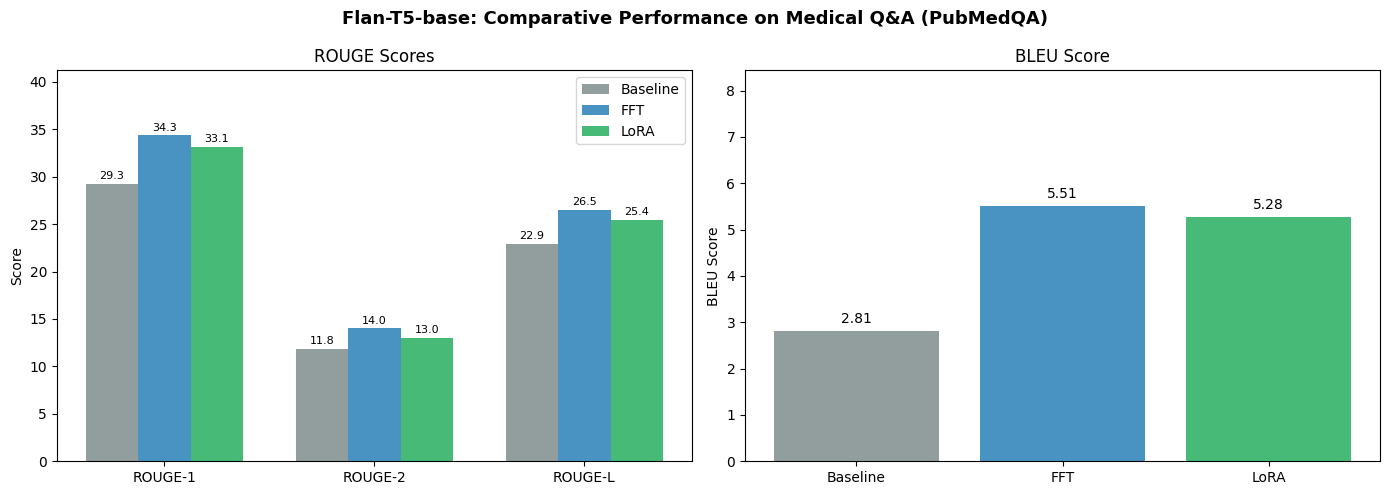

Chart saved as comparison_chart.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Flan-T5-base: Comparative Performance on Medical Q&A (PubMedQA)",
             fontsize=13, fontweight="bold")

models   = ["Baseline", "FFT", "LoRA"]
colors   = ["#7f8c8d", "#2980b9", "#27ae60"]

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
x = np.arange(len(metrics))
width = 0.25

ax = axes[0]
scores_by_model = [
    [baseline_scores["rouge1"], baseline_scores["rouge2"], baseline_scores["rougeL"]],
    [fft_scores["rouge1"],      fft_scores["rouge2"],      fft_scores["rougeL"]],
    [lora_scores["rouge1"],     lora_scores["rouge2"],     lora_scores["rougeL"]],
]
for i, (model, s) in enumerate(zip(models, scores_by_model)):
    bars = ax.bar(x + i * width, s, width, label=model, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("ROUGE Scores")
ax.legend()
ax.set_ylim(0, max([max(s) for s in scores_by_model]) * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

ax2 = axes[1]
bleu_vals = [baseline_scores["bleu"], fft_scores["bleu"], lora_scores["bleu"]]
bars2 = ax2.bar(models, bleu_vals, color=colors, alpha=0.85)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)
ax2.set_ylabel("BLEU Score")
ax2.set_title("BLEU Score")
ax2.set_ylim(0, max(bleu_vals) * 1.35 + 1)

plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as comparison_chart.png")

## 8. Qualitative Comparison

In [ ]:
print("\n" + "="*80)
print("QUALITATIVE COMPARISON — 5 Test Samples")
print("="*80)

for i in range(5):
    ex = splits["test"][i]
    ctx_list = ex["context"]["contexts"][:3]
    prompt = f"medical question: {ex['question']} context: {' '.join(ctx_list)}"
    inputs = tokenizer(prompt, return_tensors="pt", max_length=MAX_INPUT_LEN,
                       truncation=True).to(device)

    def gen(m):
        with torch.no_grad():
            o = m.generate(**inputs, max_new_tokens=MAX_TARGET_LEN, num_beams=2)
        return tokenizer.decode(o[0], skip_special_tokens=True)

    base_pred = gen(base_model)
    fft_pred  = gen(fft_model)
    lora_pred = gen(lora_model)

    print(f"\n[Sample {i+1}]")
    print(f"  Question    : {ex['question'][:120]}")
    print(f"  Ground Truth: {ex['long_answer'][:130]}")
    print(f"  Baseline    : {base_pred[:130]}")
    print(f"  FFT         : {fft_pred[:130]}")
    print(f"  LoRA        : {lora_pred[:130]}")


QUALITATIVE COMPARISON — 5 Test Samples

[Sample 1]
  Question    : Does diabetes mellitus influence the efficacy of FDG-PET in the diagnosis of cervical cancer?
  Ground Truth: In comparison with its accuracy in non-DM patients, the accuracy of PET in cervical cancer patients with mild to moderate DM was n
  Baseline    : The diagnostic power of FDG-PET in patients with cervical cancer complicated by diabetes mellitus is comparable to that of compute
  FFT         : The diagnostic power of FDG-PET in patients with DM is comparable to that of MRI/CT scans in the detection of metastatic lesions.
  LoRA        : The diagnostic power of FDG-PET in patients with DM was significantly higher than that of MRI/CT scans in patients with locally ad

[Sample 2]
  Question    : Do preoperative statins reduce atrial fibrillation after coronary artery bypass grafting?
  Ground Truth: Our study indicated that preoperative statin therapy seems to reduce AF development after CABG.
  Baseline    : Preo

## 9. Training Loss Curves

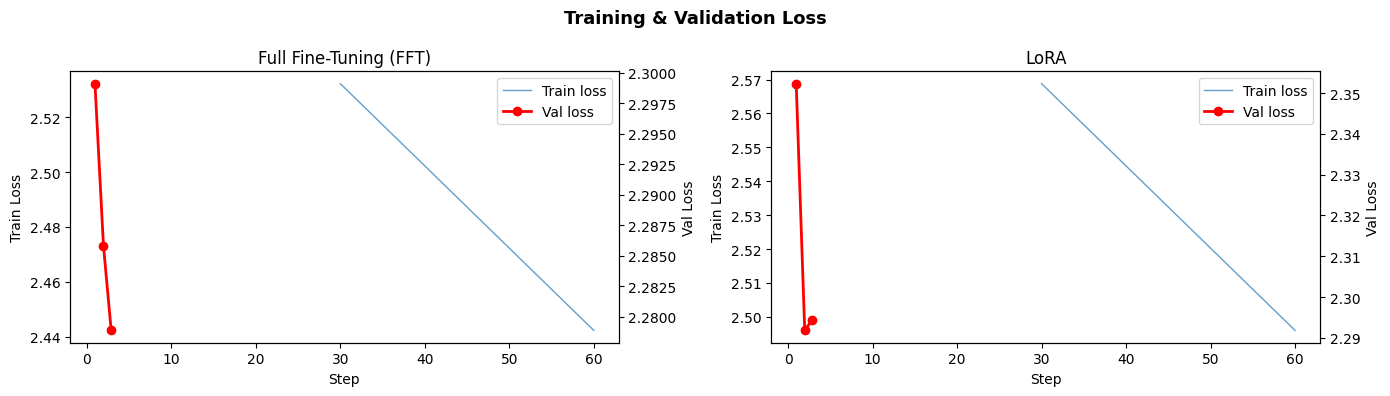

In [ ]:
def extract_losses(trainer):
    log_history = trainer.state.log_history
    train_steps, train_losses = [], []
    eval_epochs, eval_losses  = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_epochs.append(entry["epoch"])
            eval_losses.append(entry["eval_loss"])
    return train_steps, train_losses, eval_epochs, eval_losses

fft_ts,  fft_tl,  fft_es,  fft_el  = extract_losses(fft_trainer)
lora_ts, lora_tl, lora_es, lora_el = extract_losses(lora_trainer)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Training & Validation Loss", fontsize=13, fontweight="bold")

for ax, ts, tl, es, el, title in [
    (axes[0], fft_ts,  fft_tl,  fft_es,  fft_el,  "Full Fine-Tuning (FFT)"),
    (axes[1], lora_ts, lora_tl, lora_es, lora_el, "LoRA"),
]:
    ax.plot(ts, tl, label="Train loss",      alpha=0.7, linewidth=1)
    ax2_ = ax.twinx()
    ax2_.plot(es, el, "r-o", label="Val loss", linewidth=2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Train Loss")
    ax2_.set_ylabel("Val Loss")
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2_.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## **10. Implementation Report Summary**

In [ ]:
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0

report = f"""
{'='*70}
IMPLEMENTATION REPORT
{'='*70}

1. HARDWARE
   GPU             : {gpu_name}
   Total VRAM      : {gpu_mem:.1f} GB
   Platform        : Google Colab

2. MODEL & DATA
   Base Model      : google/flan-t5-base (250M parameters)
   Task            : Medical Question Answering
   Dataset         : PubMedQA (pqa_labeled, 1,000 samples)
   Splits          : Train 700 / Val 150 / Test 150
   Max Input Len   : {MAX_INPUT_LEN} tokens
   Max Target Len  : {MAX_TARGET_LEN} tokens

3. TRAINING PARAMETERS

   Full Fine-Tuning (FFT)
   ├─ Epochs        : 5 (early stopping patience=2)
   ├─ Batch Size    : 8 (train), 16 (eval)
   ├─ Learning Rate : 5e-5 (linear warmup, 100 steps)
   ├─ Optimizer     : AdamW (weight_decay=0.01)
   ├─ Precision     : fp16
   └─ Train Time    : {fft_train_time/60:.1f} min

   LoRA (PEFT)
   ├─ Rank (r)      : 16
   ├─ Alpha         : 32
   ├─ Dropout       : 0.1
   ├─ Target Modules: q, v
   ├─ Trainable     : {lora_trainable/1e6:.2f}M / {lora_all_params/1e6:.1f}M ({lora_trainable/lora_all_params*100:.1f}%)
   ├─ Epochs        : 5 (early stopping patience=2)
   ├─ Batch Size    : 8 (train), 16 (eval)
   ├─ Learning Rate : 3e-4
   ├─ Optimizer     : AdamW
   ├─ Precision     : fp16
   └─ Train Time    : {lora_train_time/60:.1f} min

4. KEY LIBRARIES
   transformers==4.40.0 | peft | datasets | evaluate
   sacrebleu | rouge_score | accelerate | torch

5. TEST-SET RESULTS
   {'Model':<22} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8} {'BLEU':>8}
   {'-'*56}
   {'Baseline':<22} {baseline_scores['rouge1']:>8} {baseline_scores['rouge2']:>8} {baseline_scores['rougeL']:>8} {baseline_scores['bleu']:>8}
   {'Full Fine-Tuning':<22} {fft_scores['rouge1']:>8} {fft_scores['rouge2']:>8} {fft_scores['rougeL']:>8} {fft_scores['bleu']:>8}
   {'LoRA':<22} {lora_scores['rouge1']:>8} {lora_scores['rouge2']:>8} {lora_scores['rougeL']:>8} {lora_scores['bleu']:>8}

{'='*70}
"""
print(report)


IMPLEMENTATION REPORT

1. HARDWARE
   GPU             : Tesla T4
   Total VRAM      : 15.6 GB
   Platform        : Google Colab

2. MODEL & DATA
   Base Model      : google/flan-t5-base (250M parameters)
   Task            : Medical Question Answering
   Dataset         : PubMedQA (pqa_labeled, 1,000 samples)
   Splits          : Train 700 / Val 150 / Test 150
   Max Input Len   : 512 tokens
   Max Target Len  : 128 tokens

3. TRAINING PARAMETERS

   Full Fine-Tuning (FFT)
   ├─ Epochs        : 5 (early stopping patience=2)
   ├─ Batch Size    : 8 (train), 16 (eval)
   ├─ Learning Rate : 5e-5 (linear warmup, 100 steps)
   ├─ Optimizer     : AdamW (weight_decay=0.01)
   ├─ Precision     : fp16
   └─ Train Time    : 14.0 min

   LoRA (PEFT)
   ├─ Rank (r)      : 16
   ├─ Alpha         : 32
   ├─ Dropout       : 0.1
   ├─ Target Modules: q, v
   ├─ Trainable     : 0.00M / 249.3M (0.0%)
   ├─ Epochs        : 5 (early stopping patience=2)
   ├─ Batch Size    : 8 (train), 16 (eval)
   ├─ Le

## **11. Critical Discussion**

In [ ]:
all_results = {
    "baseline": {**baseline_scores, "trainable_params": 0},
    "fft"     : {**fft_scores,      "trainable_params": fft_params,  "train_time_min": round(fft_train_time/60, 1)},
    "lora"    : {**lora_scores,     "trainable_params": lora_trainable, "train_time_min": round(lora_train_time/60, 1)},
}
with open("results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("Results saved to results.json")
print(json.dumps(all_results, indent=2))

Results saved to results.json
{
  "baseline": {
    "rouge1": 29.26,
    "rouge2": 11.83,
    "rougeL": 22.91,
    "bleu": 2.81,
    "trainable_params": 0
  },
  "fft": {
    "rouge1": 34.34,
    "rouge2": 14.0,
    "rougeL": 26.47,
    "bleu": 5.51,
    "trainable_params": 247577856,
    "train_time_min": 14.0
  },
  "lora": {
    "rouge1": 33.14,
    "rouge2": 12.97,
    "rougeL": 25.41,
    "bleu": 5.28,
    "trainable_params": 0,
    "train_time_min": 8.8
  }
}
